# Modelo 2.3 - Comparativa de pooling y cabeza en CNN espacial

Este notebook compara cuatro arquitecturas para deteccion de spoofing, combinando:

- pooling `(1, 8)` vs `(2, 4)` en ambas capas de `MaxPooling2D`
- cabeza `Flatten + Dense` vs `GlobalAveragePooling2D`

Modelos comparados:
- `SpatialCNN_pool_1x8_flatten`
- `SpatialCNN_pool_2x4_flatten`
- `SpatialCNN_pool_1x8_gap`
- `SpatialCNN_pool_2x4_gap`

Protocolo experimental:
1. Entrenar todos los modelos con `train`.
2. Evaluar en `dev`.
3. Evaluar en `eval`.
4. Comparar metricas para decidir el mejor compromiso entre pooling y tipo de cabeza.

In [1]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    log_loss,
    confusion_matrix,
    matthews_corrcoef,
    classification_report,
)
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option('display.max_columns', 200)
plt.style.use('default')

In [2]:
RUTA_TRAIN = '../Metricas/ETL_V2.1_train/'
RUTA_DEV = '../Metricas/ETL_V2.1_dev/'
RUTA_EVAL = '../Metricas/ETL_V2.1_eval/'


def ensure_4d(x):
    x = np.asarray(x)
    if x.ndim == 4:
        return x
    if x.ndim == 3:
        return np.expand_dims(x, axis=-1)
    if x.ndim == 5 and x.shape[-1] == 1:
        return np.squeeze(x, axis=-1)
    raise ValueError(f'Shape no soportado para Conv2D: {x.shape}')


X_train = ensure_4d(np.load(os.path.join(RUTA_TRAIN, 'X_fourier_features.npy'))).astype('float32')
y_train = np.load(os.path.join(RUTA_TRAIN, 'y_labels.npy')).astype('int32')

X_dev = ensure_4d(np.load(os.path.join(RUTA_DEV, 'X_fourier_features.npy'))).astype('float32')
y_dev = np.load(os.path.join(RUTA_DEV, 'y_labels.npy')).astype('int32')

X_eval = ensure_4d(np.load(os.path.join(RUTA_EVAL, 'X_fourier_features.npy'))).astype('float32')
y_eval = np.load(os.path.join(RUTA_EVAL, 'y_labels.npy')).astype('int32')

print('Shapes:')
print('  Train:', X_train.shape, y_train.shape)
print('  Dev  :', X_dev.shape, y_dev.shape)
print('  Eval :', X_eval.shape, y_eval.shape)

input_shape = X_train.shape[1:]

Shapes:
  Train: (25380, 5, 1025, 1) (25380,)
  Dev  : (24844, 5, 1025, 1) (24844,)
  Eval : (71237, 5, 1025, 1) (71237,)


In [3]:
def compile_binary_model(model, lr=1e-3):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')],
    )
    return model


def build_spatial_cnn(
    input_shape,
    pool_size=(1, 8),
    head_type='flatten_dense',
    name='SpatialCNN',
):
    model = models.Sequential(name=name)
    model.add(layers.Input(shape=input_shape))
    model.add(layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='Conv2D_1'))
    model.add(layers.MaxPooling2D(pool_size=pool_size, padding='same', name='MaxPool_1'))
    model.add(layers.BatchNormalization(name='BatchNorm_1'))

    model.add(layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='Conv2D_2'))
    model.add(layers.MaxPooling2D(pool_size=pool_size, padding='same', name='MaxPool_2'))
    model.add(layers.BatchNormalization(name='BatchNorm_2'))

    if head_type == 'flatten_dense':
        model.add(layers.Flatten(name='Flatten'))
        model.add(layers.Dense(128, activation='relu', name='Dense_1'))
        model.add(layers.Dropout(0.5, name='Dropout'))
    elif head_type == 'global_avg':
        model.add(layers.GlobalAveragePooling2D(name='GlobalAvgPool'))
        model.add(layers.Dense(128, activation='relu', name='Dense_1'))
        model.add(layers.Dropout(0.5, name='Dropout'))
    else:
        raise ValueError(f'head_type no soportado: {head_type}')

    model.add(layers.Dense(1, activation='sigmoid', name='Output'))
    return compile_binary_model(model)


MODEL_CONFIGS = {
    'SpatialCNN_pool_1x8_flatten': {
        'pool_size': (1, 8),
        'head_type': 'flatten_dense',
        'pool_tag': '1x8',
        'head_tag': 'flatten',
    },
    'SpatialCNN_pool_2x4_flatten': {
        'pool_size': (2, 4),
        'head_type': 'flatten_dense',
        'pool_tag': '2x4',
        'head_tag': 'flatten',
    },
    'SpatialCNN_pool_1x8_gap': {
        'pool_size': (1, 8),
        'head_type': 'global_avg',
        'pool_tag': '1x8',
        'head_tag': 'gap',
    },
    'SpatialCNN_pool_2x4_gap': {
        'pool_size': (2, 4),
        'head_type': 'global_avg',
        'pool_tag': '2x4',
        'head_tag': 'gap',
    },
}

for model_name, cfg in MODEL_CONFIGS.items():
    m = build_spatial_cnn(
        input_shape=input_shape,
        pool_size=cfg['pool_size'],
        head_type=cfg['head_type'],
        name=model_name,
    )
    print(f"\n{model_name} | pool_size={cfg['pool_size']} | head={cfg['head_type']}")
    m.summary()


SpatialCNN_pool_1x8_flatten | pool_size=(1, 8) | head=flatten_dense


Model: "SpatialCNN_pool_1x8_flatten"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_1 (Conv2D)               │ (None, 5, 1025, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 5, 129, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 5, 129, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 5, 129, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 5, 17, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 5, 17, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 5440)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 128)            │       696,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 715,777 (2.73 MB)

 Trainable params: 715,585 (2.73 MB)

...

Model: "SpatialCNN_pool_2x4_gap"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv2D_1 (Conv2D)               │ (None, 5, 1025, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 3, 257, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_1                     │ (None, 3, 257, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2D_2 (Conv2D)               │ (None, 3, 257, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 2, 65, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BatchNorm_2                     │ (None, 2, 65, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ GlobalAvgPool                   │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,649 (108.00 KB)

 Trainable params: 27,457 (107.25 KB)

 Non-trainable params: 192 (768.00 B)

In [4]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype('int32')
    y_prob = np.asarray(y_prob).ravel()
    y_pred = (y_prob >= threshold).astype('int32')

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1, zero_division=0
    )

    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_spoof': precision,
        'recall_spoof': recall,
        'f1_spoof': f1,
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
        'log_loss': log_loss(y_true, np.clip(y_prob, 1e-7, 1 - 1e-7)),
        'mcc': matthews_corrcoef(y_true, y_pred),
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp,
    }


def robust_predict_proba(model, x):
    return model.predict(x, batch_size=64, verbose=0).ravel()

In [5]:
EPOCHS = 30
BATCH_SIZE = 32

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        mode='max',
        patience=5,
        restore_best_weights=True,
        verbose=1,
    )
]

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}

print('Class weights:', class_weight)

Class weights: {0: 4.9186046511627906, 1: 0.5565789473684211}


In [6]:
results_rows = []
histories = {}
trained_models = {}

for model_name, cfg in MODEL_CONFIGS.items():
    print('\n' + '=' * 90)
    print(
        f"Entrenando {model_name} | pool_size={cfg['pool_size']} | head={cfg['head_type']}"
    )
    print('=' * 90)

    model = build_spatial_cnn(
        input_shape=input_shape,
        pool_size=cfg['pool_size'],
        head_type=cfg['head_type'],
        name=model_name,
    )

    t0 = time.time()
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_dev, y_dev),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight,
        callbacks=callbacks,
        verbose=1,
    )
    train_time = time.time() - t0

    histories[model_name] = history.history
    trained_models[model_name] = model

    for split_name, X_split, y_split in [
        ('dev', X_dev, y_dev),
        ('eval', X_eval, y_eval),
    ]:
        y_prob = robust_predict_proba(model, X_split)
        metrics = compute_metrics(y_split, y_prob, threshold=0.5)
        metrics['model'] = model_name
        metrics['split'] = split_name
        metrics['pool_size'] = cfg['pool_tag']
        metrics['head_type'] = cfg['head_tag']
        metrics['train_time_sec'] = train_time
        results_rows.append(metrics)

results_df = pd.DataFrame(results_rows)
results_df


Entrenando SpatialCNN_pool_1x8_flatten | pool_size=(1, 8) | head=flatten_dense
Epoch 1/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.5470 - auc: 0.6848 - loss: 0.6764 - val_accuracy: 0.7219 - val_auc: 0.7466 - val_loss: 0.4815
Epoch 2/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.5211 - auc: 0.7394 - loss: 0.5728 - val_accuracy: 0.5107 - val_auc: 0.7963 - val_loss: 0.5894
Epoch 3/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.5321 - auc: 0.7708 - loss: 0.5512 - val_accuracy: 0.5369 - val_auc: 0.8049 - val_loss: 0.6661
Epoch 4/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7047 - auc: 0.8167 - loss: 0.5077 - val_accuracy: 0.8153 - val_auc: 0.8977 - val_loss: 0.3993
Epoch 5/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.7817 - auc: 0.8635 - loss: 0.4548 - val_accuracy: 0.7886 - val_auc: 0.8849 - val_loss: 0.4243
Epoch 6/30
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.8312 - auc: 0.9068 - loss: 0.3845 - val_ac

,accuracy,balanced_accuracy,precision_spoof,recall_spoof,f1_spoof,roc_auc,pr_auc,log_loss,mcc,tn,fp,fn,tp,model,split,pool_size,head_type,train_time_sec
0,0.874094,0.908822,0.993766,0.865133,0.924999,0.973503,0.996567,0.283547,0.600074,2427,121,3007,19289,SpatialCNN_pool_1x8_flatten,dev,1x8,flatten,266.794956
1,0.810197,0.876487,0.994230,0.792946,0.882253,0.934931,0.992246,0.594143,0.507660,7061,294,13227,50655,SpatialCNN_pool_1x8_flatten,eval,1x8,flatten,266.794956
2,0.537273,0.645733,0.953401,0.509284,0.663919,0.717884,0.955380,0.508380,0.177002,1993,555,10941,11355,SpatialCNN_pool_2x4_flatten,dev,2x4,flatten,72.953604
3,0.778767,0.782146,0.969355,0.777887,0.863130,0.859668,0.980456,0.282194,0.382257,5784,1571,14189,49693,SpatialCNN_pool_2x4_flatten,eval,2x4,flatten,72.953604
4,0.430406,0.662842,0.986385,0.370425,0.538589,0.751352,0.964834,0.626383,0.209030,2434,114,14037,8259,SpatialCNN_pool_1x8_gap,dev,1x8,gap,61.326243
5,0.745385,0.836380,0.992252,0.721706,0.835626,0.864542,0.983831,0.351639,0.429826,6995,360,17778,46104,SpatialCNN_pool_1x8_gap,eval,1x8,gap,61.326243
6,0.576799,0.650374,0.949969,0.557813,0.702894,0.728850,0.960842,0.550783,0.182750,1893,655,9859,12437,SpatialCNN_pool_2x4_gap,dev,2x4,gap,64.878029
7,0.798784,0.770869,0.963620,0.806049,0.877819,0.864698,0.983887,0.295077,0.380742,5411,1944,12390,51492,SpatialCNN_pool_2x4_gap,eval,2x4,gap,64.878029


In [7]:
metric_cols = [
    'accuracy',
    'balanced_accuracy',
    'precision_spoof',
    'recall_spoof',
    'f1_spoof',
    'roc_auc',
    'pr_auc',
    'mcc',
    'log_loss',
]

summary_table = (
    results_df[['model', 'split', 'pool_size', 'head_type'] + metric_cols + ['train_time_sec']]
    .sort_values(['split', 'balanced_accuracy'], ascending=[True, False])
    .reset_index(drop=True)
)

print('=== Comparativa final por modelo y split ===')
display(summary_table.round(4))

print('=== Promedio por head_type y split ===')
display(
    summary_table
    .groupby(['split', 'head_type'], as_index=False)[['balanced_accuracy', 'f1_spoof', 'mcc', 'roc_auc']]
    .mean()
    .sort_values(['split', 'balanced_accuracy'], ascending=[True, False])
    .round(4)
)

print('=== Promedio por pool_size y split ===')
display(
    summary_table
    .groupby(['split', 'pool_size'], as_index=False)[['balanced_accuracy', 'f1_spoof', 'mcc', 'roc_auc']]
    .mean()
    .sort_values(['split', 'balanced_accuracy'], ascending=[True, False])
    .round(4)
)

=== Comparativa final por modelo y split ===


,model,split,pool_size,head_type,accuracy,balanced_accuracy,precision_spoof,recall_spoof,f1_spoof,roc_auc,pr_auc,mcc,log_loss,train_time_sec
0,SpatialCNN_pool_1x8_flatten,dev,1x8,flatten,0.8741,0.9088,0.9938,0.8651,0.9250,0.9735,0.9966,0.6001,0.2835,266.7950
1,SpatialCNN_pool_1x8_gap,dev,1x8,gap,0.4304,0.6628,0.9864,0.3704,0.5386,0.7514,0.9648,0.2090,0.6264,61.3262
2,SpatialCNN_pool_2x4_gap,dev,2x4,gap,0.5768,0.6504,0.9500,0.5578,0.7029,0.7288,0.9608,0.1828,0.5508,64.8780
3,SpatialCNN_pool_2x4_flatten,dev,2x4,flatten,0.5373,0.6457,0.9534,0.5093,0.6639,0.7179,0.9554,0.1770,0.5084,72.9536
4,SpatialCNN_pool_1x8_flatten,eval,1x8,flatten,0.8102,0.8765,0.9942,0.7929,0.8823,0.9349,0.9922,0.5077,0.5941,266.7950
5,SpatialCNN_pool_1x8_gap,eval,1x8,gap,0.7454,0.8364,0.9923,0.7217,0.8356,0.8645,0.9838,0.4298,0.3516,61.3262
6,SpatialCNN_pool_2x4_flatten,eval,2x4,flatten,0.7788,0.7821,0.9694,0.7779,0.8631,0.8597,0.9805,0.3823,0.2822,72.9536
7,SpatialCNN_pool_2x4_gap,eval,2x4,gap,0.7988,0.7709,0.9636,0.8060,0.8778,0.8647,0.9839,0.3807,0.2951,64.8780


=== Promedio por head_type y split ===


,split,head_type,balanced_accuracy,f1_spoof,mcc,roc_auc
0,dev,flatten,0.7773,0.7945,0.3885,0.8457
1,dev,gap,0.6566,0.6207,0.1959,0.7401
2,eval,flatten,0.8293,0.8727,0.4450,0.8973
3,eval,gap,0.8036,0.8567,0.4053,0.8646


=== Promedio por pool_size y split ===


,split,pool_size,balanced_accuracy,f1_spoof,mcc,roc_auc
0,dev,1x8,0.7858,0.7318,0.4046,0.8624
1,dev,2x4,0.6481,0.6834,0.1799,0.7234
2,eval,1x8,0.8564,0.8589,0.4687,0.8997
3,eval,2x4,0.7765,0.8705,0.3815,0.8622


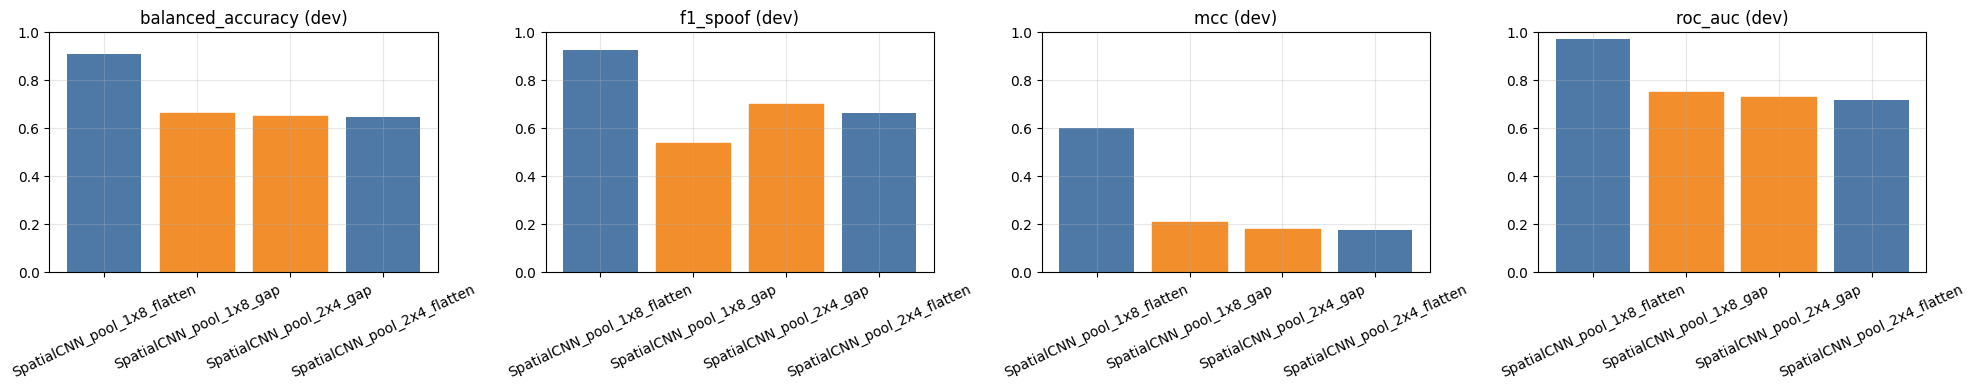

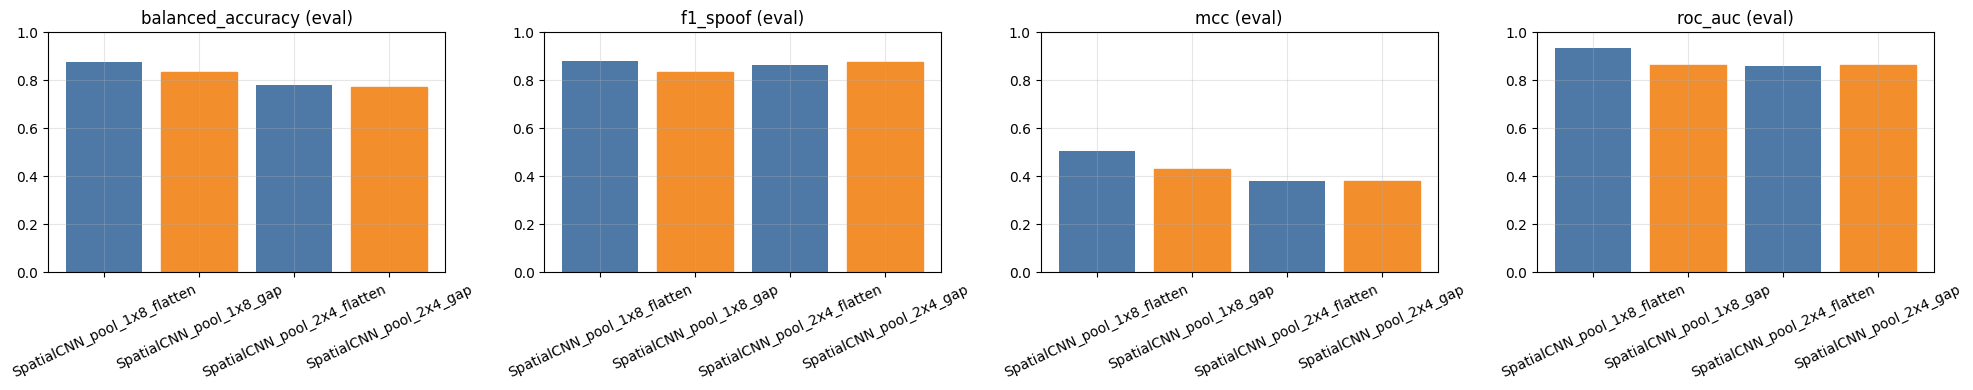


Mejor modelo por split (balanced_accuracy):


,split,model,pool_size,head_type,balanced_accuracy,f1_spoof,mcc,roc_auc
0,dev,SpatialCNN_pool_1x8_flatten,1x8,flatten,0.9088,0.9250,0.6001,0.9735
1,eval,SpatialCNN_pool_1x8_flatten,1x8,flatten,0.8765,0.8823,0.5077,0.9349



Comparativa por head_type | split=dev


,head_type,balanced_accuracy,f1_spoof,mcc,roc_auc
0,flatten,0.7773,0.7945,0.3885,0.8457
1,gap,0.6566,0.6207,0.1959,0.7401


Comparativa por pool_size | split=dev


,pool_size,balanced_accuracy,f1_spoof,mcc,roc_auc
0,1x8,0.7858,0.7318,0.4046,0.8624
1,2x4,0.6481,0.6834,0.1799,0.7234



Comparativa por head_type | split=eval


,head_type,balanced_accuracy,f1_spoof,mcc,roc_auc
0,flatten,0.8293,0.8727,0.4450,0.8973
1,gap,0.8036,0.8567,0.4053,0.8646


Comparativa por pool_size | split=eval


,pool_size,balanced_accuracy,f1_spoof,mcc,roc_auc
0,1x8,0.8564,0.8589,0.4687,0.8997
1,2x4,0.7765,0.8705,0.3815,0.8622


In [8]:
for split_name in ['dev', 'eval']:
    df_split = summary_table[summary_table['split'] == split_name].copy()

    fig, axes = plt.subplots(1, 4, figsize=(20, 4))
    for ax, metric in zip(axes, ['balanced_accuracy', 'f1_spoof', 'mcc', 'roc_auc']):
        bars = ax.bar(df_split['model'], df_split[metric], color='#4e79a7')
        ax.set_title(f'{metric} ({split_name})')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=25)
        ax.grid(alpha=0.3)

        for b, head in zip(bars, df_split['head_type']):
            if head == 'gap':
                b.set_color('#f28e2b')

    plt.tight_layout()
    plt.show()

print('\nMejor modelo por split (balanced_accuracy):')
display(
    summary_table.sort_values(['split', 'balanced_accuracy'], ascending=[True, False])
    .groupby('split', as_index=False)
    .first()[['split', 'model', 'pool_size', 'head_type', 'balanced_accuracy', 'f1_spoof', 'mcc', 'roc_auc']]
    .round(4)
)

for split_name in ['dev', 'eval']:
    df_split = summary_table[summary_table['split'] == split_name]

    head_cmp = (
        df_split.groupby('head_type', as_index=False)[['balanced_accuracy', 'f1_spoof', 'mcc', 'roc_auc']]
        .mean()
        .sort_values('balanced_accuracy', ascending=False)
    )
    pool_cmp = (
        df_split.groupby('pool_size', as_index=False)[['balanced_accuracy', 'f1_spoof', 'mcc', 'roc_auc']]
        .mean()
        .sort_values('balanced_accuracy', ascending=False)
    )

    print(f'\nComparativa por head_type | split={split_name}')
    display(head_cmp.round(4))
    print(f'Comparativa por pool_size | split={split_name}')
    display(pool_cmp.round(4))

In [9]:
for model_name, model in trained_models.items():
    for split_name, X_split, y_split in [('dev', X_dev, y_dev), ('eval', X_eval, y_eval)]:
        y_prob = robust_predict_proba(model, X_split)
        y_pred = (y_prob >= 0.5).astype('int32')

        print('\n' + '=' * 90)
        print(f'{model_name} | split={split_name}')
        print('=' * 90)
        print(classification_report(y_split, y_pred, target_names=['bonafide', 'spoof'], digits=4))


SpatialCNN_pool_1x8_flatten | split=dev
              precision    recall  f1-score   support

    bonafide     0.4466    0.9525    0.6081      2548
       spoof     0.9938    0.8651    0.9250     22296

    accuracy                         0.8741     24844
   macro avg     0.7202    0.9088    0.7666     24844
weighted avg     0.9377    0.8741    0.8925     24844


SpatialCNN_pool_1x8_flatten | split=eval
              precision    recall  f1-score   support

    bonafide     0.3480    0.9600    0.5109      7355
       spoof     0.9942    0.7929    0.8823     63882

    accuracy                         0.8102     71237
   macro avg     0.6711    0.8765    0.6966     71237
weighted avg     0.9275    0.8102    0.8439     71237


SpatialCNN_pool_2x4_flatten | split=dev
              precision    recall  f1-score   support

    bonafide     0.1541    0.7822    0.2575      2548
       spoof     0.9534    0.5093    0.6639     22296

    accuracy                         0.5373     24844
   m

C:\Users\Lechu\AppData\Local\Temp\ipykernel_15004\25963505.py:26: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


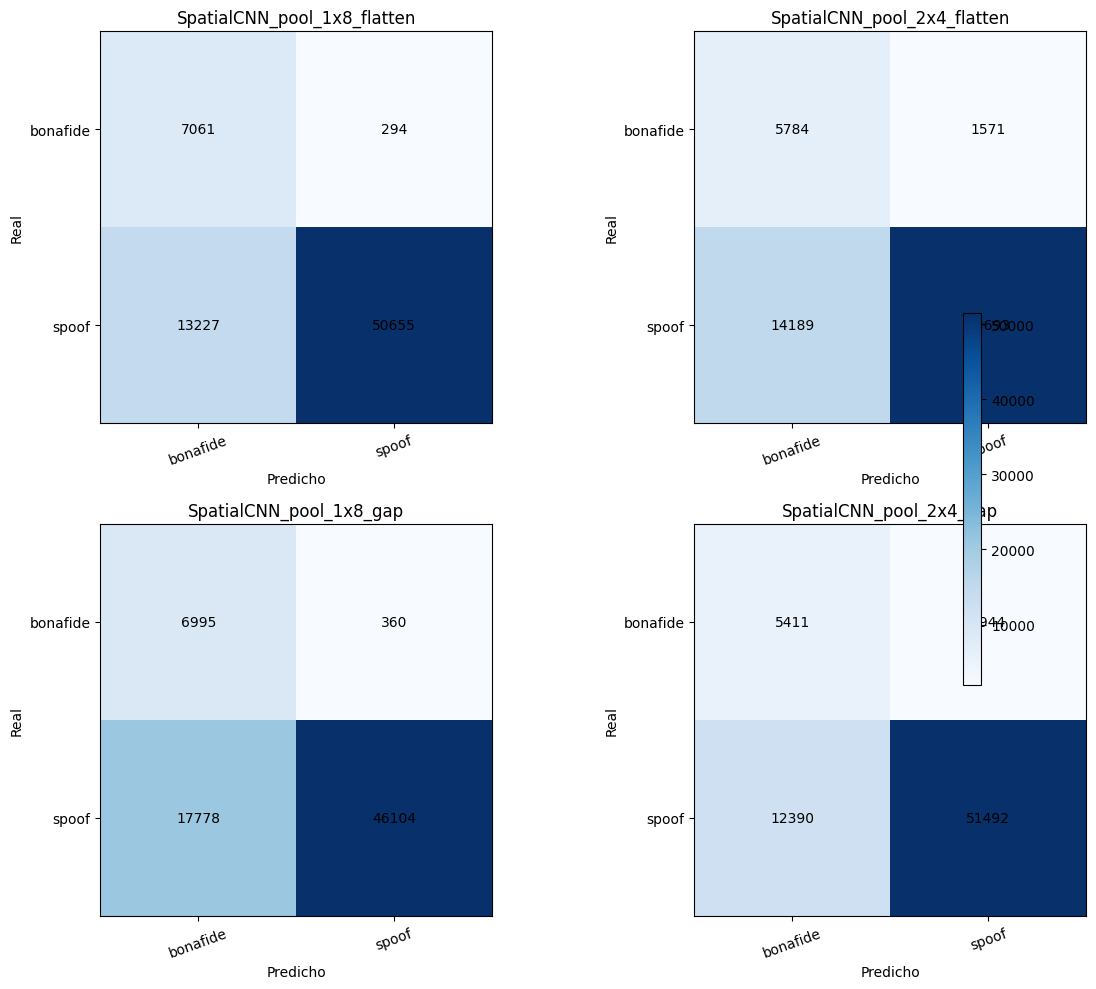

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

model_names = list(MODEL_CONFIGS.keys())

for ax, model_name in zip(axes, model_names):
    model = trained_models[model_name]
    y_prob = robust_predict_proba(model, X_eval)
    y_pred = (y_prob >= 0.5).astype('int32')

    cm = confusion_matrix(y_eval, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(model_name)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['bonafide', 'spoof'], rotation=20)
    ax.set_yticklabels(['bonafide', 'spoof'])

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', color='black')

fig.colorbar(im, ax=axes.tolist(), fraction=0.02, pad=0.02)
plt.tight_layout()
plt.show()

## Conclusiones

De acuerdo con los resultados obtenidos en este experimento (entrenamiento en `train`, validacion en `dev` y test en `eval`), el modelo con mejor desempeno global es:

- **`SpatialCNN_pool_1x8_flatten`** (pooling `(1,8)` + cabeza `Flatten + Dense`).

### Mejor modelo por metrica

- **Balanced Accuracy**
  - `dev`: `SpatialCNN_pool_1x8_flatten` (**0.9088**)
  - `eval`: `SpatialCNN_pool_1x8_flatten` (**0.8765**)

- **MCC**
  - `dev`: `SpatialCNN_pool_1x8_flatten` (**0.6001**)
  - `eval`: `SpatialCNN_pool_1x8_flatten` (**0.5077**)

- **F1_spoof**
  - `dev`: `SpatialCNN_pool_1x8_flatten` (**0.9250**)
  - `eval`: `SpatialCNN_pool_1x8_flatten` (**0.8823**)

### Conclusion final

Con las tres metricas principales analizadas (`balanced_accuracy`, `MCC` y `F1_spoof`), el ranking es consistente y confirma que **`SpatialCNN_pool_1x8_flatten`** es la opcion mas robusta entre las cuatro arquitecturas evaluadas en esta corrida.